# US equities panel: what the one holdout was spent on, and what it bought

This notebook reads the immutable validation backtest set, applies the selection rule to it, and
resolves the holdout evaluation of whatever that rule chose. The selection rule is one sentence:
the configuration with the highest validation backtest Sharpe, ties broken by backtest hash.
Reopening every reference through the registry rather than by hand makes the assessment
independent of registry row order and of any experiments added later.

**Learning objectives**

- Reproduce deterministic validation selection from one immutable backtest set.
- Verify that the holdout evaluation is the selected configuration refitted, and nothing else.
- Interpret performance with uncertainty intervals and exact paired comparisons.
- Compare return and drawdown paths without mixing validation and holdout observations.
- Distinguish predictive validation evidence from the single holdout assessment.

**Book reference**: Chapters 16-20 for signal evaluation, allocation, trading costs, risk, and
strategy assessment.

**Prerequisites**: [`18_risk_management`](18_risk_management.ipynb) has frozen the per-label
validation strategy set this notebook opens;
[`20_holdout_predictions`](20_holdout_predictions.ipynb) has registered the refit and
[`21_holdout_backtest`](21_holdout_backtest.ipynb) the backtest of it.

**What it writes**: `backtest_paired_metrics`, and nothing else. It refits nothing and
registers no backtest - the pairs are bootstrap comparisons between return series that
already exist. Everything else here reads the registry, applies the selection rule and
reports.

In [1]:
"""Assessment of one validation and holdout lineage, and the paired evidence for it."""

import json

import matplotlib.pyplot as plt
import numpy as np
import polars as pl

from case_studies.research import (
    BacktestResult,
    CandidateSet,
    Study,
    split_unpublished_members,
)
from case_studies.research.holdout import build_holdout_training_spec
from case_studies.research.strategy import strategy_warmup_periods
from case_studies.utils.artifact_digest import value_digest
from case_studies.utils.backtest_loaders import load_backtest_prices_for
from case_studies.utils.paired_metrics import populate_paired_metrics
from case_studies.utils.registry import (
    load_backtest_metrics,
    load_paired_metrics,
    load_prediction_index,
    training_hash_from_spec,
)
from case_studies.utils.registry.specs import project_training_identity
from case_studies.utils.strategy_analysis import (
    resolve_solvent_carrier,
    select_holdout_self_backtest,
)
from utils.style import COLORS, add_message_title, show_with_alt

In [2]:
CASE_STUDY_ID = "us_equities_panel"
VALIDATION_BACKTEST_SET_NAME = "us-equities-fwd-ret-1d-validation-strategies-v1"

## Reopen the validation set

Candidate-set members are complete canonical validation backtests with an explicit comparison
protocol. Selection uses validation backtest Sharpe, with the backtest hash as the deterministic
tie-breaker. That rule is the whole of the selection: the configuration with the highest
validation Sharpe is the one the holdout ran.

In [3]:
if not VALIDATION_BACKTEST_SET_NAME:
    raise ValueError("VALIDATION_BACKTEST_SET_NAME is required")

study = Study.open(CASE_STUDY_ID)
# 20 is read-only and canonical throughout, so this is `study.root`; naming it through
# `storage_root` keeps the metric reads answering "this tier's registry" rather than assuming it.
metrics_case_dir = study.storage_root()
validation_set = CandidateSet.one(study, name=VALIDATION_BACKTEST_SET_NAME)

if validation_set.member_kind != "backtest":
    raise ValueError("strategy selection requires a backtest candidate set")

## Validate the comparison protocol

The official analysis restricts the general candidate-set abstraction to one canonical comparison
protocol. Each backtest must use the canonical validation price window plus its declared warmup.

**The set must hold one label.** Selection here is the deterministic validation rule applied
once, and the holdout it leads to is used once - so what the ranking is taken over decides what
that single use buys. A set spanning `fwd_ret_1d`, `fwd_ret_5d` and `fwd_ret_21d` would rank a
one-day-horizon Sharpe against a twenty-one-day one and spend the holdout on a cross-horizon
comparison, which is not the question the funnel asks. Every case study in the book runs the
funnel once per label for that reason. Requiring `label_artifact` to be constant across the set
is how
that is enforced, and it is why the set this notebook opens is one of the per-label sets rather
than a union of them. `feature_artifacts` and `cv` are allowed to vary: within a label the funnel
ranks model families against each other, and they do not share a feature lineage -
`latent_factors` builds `feature_artifacts` from `input_lineage["files"]` and the rest from
`["artifacts"]`. Requiring all three constant would reject every set the funnel produces.

In [4]:
CONSTANT_IDENTITY_FIELDS = {"label_artifact"}
comparable_fields = set(validation_set.comparison_contract.get("comparable_fields", ()))
varying_identity_fields = CONSTANT_IDENTITY_FIELDS & comparable_fields
if varying_identity_fields:
    raise ValueError(
        "validation set varies identity fields, so one ranking would compare across labels: "
        f"{sorted(varying_identity_fields)}"
    )
validation_protocol = validation_set.comparison_contract.get("protocol", {})
missing_identity_fields = {
    field for field in CONSTANT_IDENTITY_FIELDS if not validation_protocol.get(field)
}
if missing_identity_fields:
    raise ValueError(f"validation set lacks identity fields {sorted(missing_identity_fields)}")
if (
    validation_protocol.get("split") != "validation"
    or validation_protocol.get("execution_tier") != "canonical"
):
    raise ValueError("strategy analysis requires canonical validation results")

Every member must reproduce the canonical validation price identity for its own label and warmup
requirement.

In [5]:
canonical_price_digests = {}
for candidate_hash in validation_set.members:
    candidate = study.results.open(candidate_hash)
    if not isinstance(candidate, BacktestResult) or not candidate.complete:
        raise ValueError(f"{candidate_hash} is not a complete backtest result")
    candidate_protocol = candidate.protocol()
    missing_identity_fields = {
        field
        for field in ("label_artifact", "feature_artifacts", "cv")
        if not candidate_protocol.get(field)
    }
    if missing_identity_fields:
        raise ValueError(
            f"{candidate_hash} lacks input identity fields {sorted(missing_identity_fields)}"
        )
    if any(
        candidate_protocol.get(field) != validation_protocol[field]
        for field in (*CONSTANT_IDENTITY_FIELDS, "split", "execution_tier")
    ):
        raise ValueError(f"{candidate_hash} differs from the validation input protocol")
    training_spec = candidate.lineage()["training_spec"]
    label = training_spec.get("label")
    if not label:
        raise ValueError(f"{candidate_hash} has no label")
    strategy_spec = candidate.spec()
    warmup_periods = strategy_warmup_periods(strategy_spec)
    price_key = (str(label), warmup_periods)
    if price_key not in canonical_price_digests:
        canonical_prices = load_backtest_prices_for(
            CASE_STUDY_ID,
            str(label),
            split="validation",
            warmup_periods=warmup_periods,
        )
        canonical_price_digests[price_key] = value_digest(canonical_prices)
    if strategy_spec.get("input_identity", {}).get("prices") != canonical_price_digests[price_key]:
        raise ValueError(f"{candidate_hash} does not use canonical validation prices")

Apply the selection rule only after every member has passed the protocol checks. The
candidate set says which backtests may be chosen from; `resolve_solvent_carrier` says which
one is chosen, and it is handed the set rather than the whole registry. It is the same
resolver [`20_holdout_predictions`](20_holdout_predictions.ipynb) and
[`21_holdout_backtest`](21_holdout_backtest.ipynb) use.

In [6]:
carrier = resolve_solvent_carrier(CASE_STUDY_ID, admitted=frozenset(validation_set.members))
selected_validation = study.results.open(carrier["val_backtest_hash"])
if not isinstance(selected_validation, BacktestResult) or not selected_validation.complete:
    raise ValueError("selected validation backtest is incomplete")
if selected_validation.execution_tier != "canonical":
    raise ValueError("selected validation backtest is not canonical")

print(f"Validation set: {validation_set.hash} ({len(validation_set.members)} backtests)")
print(f"Selected validation backtest: {selected_validation.hash}")

Validation set: 2a3f33715b63 (538 backtests)
Selected validation backtest: 3076efd14f7c


The selected result is reconstructed through the catalog, so the prediction set, training run
and strategy specification below are the ones the registry records for it rather than values
carried in by hand.

In [7]:
selected_record = selected_validation.registry_record()
selected_prediction = study.results.open(selected_record["prediction_hash"])
selected_prediction_record = selected_prediction.registry_record()
selected_training = study.results.open(selected_prediction_record["training_hash"])
selected_training_record = selected_training.registry_record()
selected_training_spec = selected_training.spec()
selected_training_identity = project_training_identity(selected_training_spec)
selected_training_computation = selected_training_identity.get(
    "computation", selected_training_identity
)

## Validation selection evidence

Every candidate remains visible in the evidence table. Sorting by Sharpe and then hash reproduces
the selection rule, while all other metrics remain descriptive. Cost sensitivity is excluded from
the rule by the candidate set's eligibility contract.

In [8]:
required_selection_metrics = {"sharpe", "sharpe_ci95_lo", "sharpe_ci95_hi"}
candidate_catalog = study.backtests.table().filter(
    pl.col("backtest_hash").is_in(validation_set.members)
)
candidate_catalog = candidate_catalog.drop(
    *sorted(required_selection_metrics & set(candidate_catalog.columns))
)
metric_frames = []
for candidate_hash in validation_set.members:
    metrics = load_backtest_metrics(
        CASE_STUDY_ID,
        backtest_hash=candidate_hash,
        case_dir=metrics_case_dir,
    )
    if metrics.height != 1 or not required_selection_metrics <= set(metrics.columns):
        raise ValueError(f"missing exact selection metrics for {candidate_hash}")
    metric_frames.append(metrics.select("backtest_hash", *sorted(required_selection_metrics)))
selection_metrics = pl.concat(metric_frames, how="vertical_relaxed")
selection_evidence = candidate_catalog.join(
    selection_metrics,
    on="backtest_hash",
    how="inner",
    validate="1:1",
    suffix="_exact",
)

The joined rows must reproduce exact set membership. Canonical tier, validation split, complete
prediction coverage, eligible strategy stage, and finite Sharpe evidence are required for every
member.

In [9]:
if selection_evidence.height != len(validation_set.members):
    raise ValueError("validation set contains incomplete selection evidence")
if set(selection_evidence["backtest_hash"]) != set(validation_set.members):
    raise ValueError("selection evidence differs from candidate-set membership")
if selection_evidence.filter(
    (pl.col("execution_tier") != "canonical")
    | (pl.col("split") != "validation")
    | (~pl.col("complete"))
    | (~pl.col("stage").is_in(["signal", "allocation", "risk_overlay"]))
).height:
    raise ValueError("validation set contains an ineligible selection member")
if not required_selection_metrics <= set(selection_evidence.columns) or any(
    selection_evidence[name].null_count() or not selection_evidence[name].is_finite().all()
    for name in required_selection_metrics
):
    raise ValueError("validation set contains a non-finite selection metric")

selection_evidence = selection_evidence.sort(["sharpe", "backtest_hash"], descending=[True, False])
if selected_validation.hash not in selection_evidence["backtest_hash"].to_list():
    raise ValueError("the selected configuration is not among the candidates this table describes")
# The stored Sharpe orders the table; the selection ordered over the shared span. Where the two
# disagree the line below says so.
if selection_evidence["backtest_hash"][0] != selected_validation.hash:
    print(
        f"stored-Sharpe order leads with {selection_evidence['backtest_hash'][0]}; the selected configuration "
        f"is {selected_validation.hash}, selected over the sessions every candidate prices"
    )
selection_evidence

catalog_version,origin,identity_status,family,config_name,label,split,checkpoint_kind,checkpoint_value,stage,execution_tier,approval,completion_state,complete,created_at,metrics_computed_at,artifact_available,signal_method,allocation_method,risk_method,decision_artifact_hash,sortino,total_return,max_drawdown,cagr,volatility,calmar,omega,stability,tail_ratio,win_rate,kurtosis,skewness,var_95,cvar_95,n_periods,num_trades,…,model__params__factor_ridge,model__params__gamma_ridge,model__params__hidden_dim,model__params__hidden_size,model__params__lookback,model__params__max_iter,model__params__n_epochs,model__params__n_layers,model__params__n_members,preprocessing__calendar_id,preprocessing__class,preprocessing__gap_policy,preprocessing__imputer__class,preprocessing__imputer__strategy,preprocessing__lookback,preprocessing__scaler__class,preprocessing__scaler__with_mean,preprocessing__scaler__with_std,strategy__allocation__calibration_version,strategy__allocation__lookback,strategy__allocation__method,strategy__allocation__min_calibration_n,strategy__allocation__sparse_fallback,strategy__allocation__vol_window,strategy__rebalance__cadence,strategy__rebalance__min_trade_value,strategy__rebalance__min_weight_change,strategy__rebalance__mode,strategy__rebalance__step,strategy__risk__name,strategy__risk__position_rules,strategy__signal__long_short,strategy__signal__method,strategy__signal__top_k,sharpe,sharpe_ci95_hi,sharpe_ci95_lo
i64,str,str,str,str,str,str,str,i64,str,str,str,str,bool,str,str,bool,str,str,str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,…,f64,f64,i64,i64,i64,i64,i64,i64,i64,str,str,str,str,str,i64,str,bool,bool,str,i64,str,i64,str,i64,str,f64,f64,str,i64,str,str,bool,str,i64,f64,f64,f64
1,"""released""","""current""","""gbm""","""leaves_63_mse""","""fwd_ret_1d""","""validation""","""iteration""",500,"""signal""","""canonical""","""unapproved""","""complete""",true,"""2026-09-14T18:28:35.717685+00:…","""2026-09-14T18:28:35.756178+00:…",true,"""equal_weight_top_k""",null,null,null,1.721017,145.044362,-0.98961,0.353424,0.342475,0.357134,1.218016,0.025414,1.207868,0.492048,9.860217,1.151321,-0.028968,-0.043536,4150.0,121521.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""daily_close""",100.0,0.005,"""engine""",1,null,null,true,"""equal_weight_top_k""",20,1.052785,1.659745,0.494042
1,"""released""","""current""","""gbm""","""leaves_63_mse""","""fwd_ret_1d""","""validation""","""iteration""",500,"""risk_overlay""","""canonical""","""unapproved""","""complete""",true,"""2026-09-14T23:39:07.780839+00:…","""2026-09-14T23:39:07.791178+00:…",true,"""equal_weight_top_k""",null,"""time_exit_40""",null,1.721017,145.044362,-0.98961,0.353424,0.342475,0.357134,1.218016,0.025414,1.207868,0.492048,9.860217,1.151321,-0.028968,-0.043536,4150.0,121521.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""daily_close""",100.0,0.005,"""engine""",1,"""time_exit_40""","""[{""bars"":40,""type"":""time_exit""…",true,"""equal_weight_top_k""",20,1.052785,1.659745,0.494042
1,"""released""","""current""","""gbm""","""leaves_63_mse""","""fwd_ret_1d""","""validation""","""iteration""",500,"""risk_overlay""","""canonical""","""unapproved""","""complete""",true,"""2026-09-14T23:36:18.546558+00:…","""2026-09-14T23:36:18.557782+00:…",true,"""equal_weight_top_k""",null,"""time_exit_20""",null,1.715293,142.684027,-0.989628,0.352085,0.342561,0.355775,1.217307,0.025323,1.207967,0.492048,9.850966,1.149281,-0.028966,-0.043579,4150.0,121526.0,…,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,null,"""daily_close""",100.0,0.005,"""engine""",1,"""time_exit_20""","""[{""bars"":20,""type"":""time_exit""…",true,"""equal_weight_top_k""",20,1.049717,1.653843,0.489688
1,"""released""","""current""","""gbm""","""leaves_63_mse""","""f

## Resolve the exact holdout evaluation

The holdout lineage is resolved from the registry, by matching the selected validation
backtest's own strategy specification against the holdout backtests registered for the same
configuration. That is what makes this the replay of the selected strategy rather than
whichever holdout backtest happens to score best - reading the holdout to choose among
configurations is the one thing the funnel forbids.

In [10]:
holdout_backtest_hash = select_holdout_self_backtest(CASE_STUDY_ID, selected_validation.hash)
if holdout_backtest_hash is None:
    raise ValueError(
        f"no holdout backtest replays the selected validation strategy "
        f"{selected_validation.hash}; run 20_holdout_predictions and 21_holdout_backtest first"
    )
holdout_backtest = study.results.open(holdout_backtest_hash)
holdout_prediction = study.results.open(holdout_backtest.registry_record()["prediction_hash"])
holdout_training = study.results.open(holdout_prediction.registry_record()["training_hash"])

if not isinstance(holdout_backtest, BacktestResult) or not holdout_backtest.complete:
    raise ValueError("holdout backtest is incomplete")
if holdout_backtest.execution_tier != "canonical":
    raise ValueError("holdout backtest is not canonical")
if holdout_prediction.registry_record()["split"] != "holdout":
    raise ValueError("holdout prediction has the wrong split")
if holdout_prediction.registry_record()["training_hash"] != holdout_training.hash:
    raise ValueError("holdout training and prediction lineage disagree")

The holdout lineage must be the selected configuration refitted, differing from the validation
run only in its training interval and the window it predicts over. The checkpoint is part of the
configuration, so it has to be the same one; the strategy has to be the same specification; and
the training identity has to be a NEW one, because the holdout fold is not a validation fold and
a run that came back with the validation hash did not refit.

In [11]:
selected_label = selected_training.spec()["label"]
selected_checkpoint = (
    selected_prediction_record["checkpoint_kind"],
    selected_prediction_record["checkpoint_value"],
)
holdout_prediction_record = holdout_prediction.registry_record()
holdout_checkpoint = (
    holdout_prediction_record["checkpoint_kind"],
    holdout_prediction_record["checkpoint_value"],
)
if holdout_checkpoint != selected_checkpoint:
    raise ValueError(
        f"holdout checkpoint {holdout_checkpoint} is not the selected checkpoint "
        f"{selected_checkpoint}"
    )
if holdout_training.hash == selected_training.hash:
    raise ValueError(
        "the holdout carries the validation training identity, which means it was not refitted"
    )

**Finding the holdout replay is not the same as proving it is the same configuration.** The
resolver matches on the declared configuration - family, configuration name, label, checkpoint -
and on the strategy specification, and a refit under changed feature artifacts or changed model
parameters keeps its configuration name and would match all of that.

So the specification the holdout should have been fitted under is rebuilt here from the selected
validation specification, and its identity is compared against the one the holdout actually
registered under. That hash covers the feature lineage, the model parameters and the
cross-validation interval, so agreement is the whole claim rather than a sample of it.
Disagreement means the holdout on file answers a different question from the one the validation
selection asked.

In [12]:
expected_holdout_spec = build_holdout_training_spec(
    study,
    selected_training.spec(),
    timeline=(
        pl.read_parquet(study.root / "labels" / f"{selected_label}.parquet")
        .get_column("timestamp")
        .unique()
        .sort()
        .to_list()
    ),
    case_study=CASE_STUDY_ID,
)
expected_holdout_hash = training_hash_from_spec(expected_holdout_spec)
if holdout_training.hash != expected_holdout_hash:
    raise ValueError(
        f"the registered holdout refit {holdout_training.hash} is not the one this validation "
        f"selection derives ({expected_holdout_hash}); its feature lineage, model parameters or "
        "training interval differ from the selected configuration's"
    )
if holdout_backtest.registry_record()["prediction_hash"] != holdout_prediction.hash:
    raise ValueError("holdout backtest and prediction lineage disagree")
if holdout_backtest.spec().get("strategy") != selected_validation.spec().get("strategy"):
    raise ValueError("holdout strategy differs from the selected validation strategy")
if not holdout_backtest.spec().get("input_identity", {}).get("prices"):
    raise ValueError("holdout backtest lacks canonical price identity")

### Two kinds of check, and why they differ

Everything above this point is an **identity** check and demands equality with the selected
validation lineage: the checkpoint, the strategy specification, the prediction lineage and the
canonical price identity, plus the one field that must DIFFER, the training hash. Each of those
can move a number, so a difference in the wrong direction means the holdout result does not
answer the question the validation selection asked.

The two below are **operational provenance** and demand only presence. `git_commit` and
`runtime_json` record which commit and which machine produced a result; they cannot change one.
The holdout is evaluated after the validation sweep, so it legitimately runs from a later commit
on a differently-configured machine, and requiring them to match would forbid the sequence the
protocol prescribes. Requiring them to exist is what remains meaningful: a result with no
recorded commit or runtime cannot be traced back to anything.

The distinction is not "strict versus lenient". Every field that can change the reported number
is checked exactly, and the two that cannot are checked for presence.

In [13]:
holdout_training_record = holdout_training.registry_record()
holdout_runtime_provenance = json.loads(holdout_training_record.get("runtime_json") or "{}")
if not holdout_training_record.get("git_commit") or not holdout_runtime_provenance:
    raise ValueError("holdout training lacks operational provenance")

if holdout_training.spec()["label"] != selected_label:
    raise ValueError("holdout label differs from the selected label")

print(f"Selected label: {selected_label}")
print(f"Holdout training: {holdout_training.hash}")
print(f"Holdout prediction: {holdout_prediction.hash}")
print(f"Holdout backtest: {holdout_backtest.hash}")

Selected label: fwd_ret_1d
Holdout training: 0a4c916e2937
Holdout prediction: 192a4ddac3c1
Holdout backtest: 6f3181b567df


## Validation and holdout performance

Point estimates and bootstrap intervals are read by exact backtest hash. The two windows are
displayed together for assessment, while their statistical difference comes from the registered
independent-window comparison in the next section.

In [14]:
required_performance_metrics = {
    "sharpe",
    "sharpe_ci95_lo",
    "sharpe_ci95_hi",
    "total_return",
    "max_drawdown",
    "max_dd_ci95_lo",
    "max_dd_ci95_hi",
    "volatility",
    "avg_turnover",
    "num_trades",
}
performance_rows = []

for period, result in (
    ("validation", selected_validation),
    ("holdout", holdout_backtest),
):
    metrics = load_backtest_metrics(
        CASE_STUDY_ID,
        backtest_hash=result.hash,
        case_dir=metrics_case_dir,
    )
    if metrics.height != 1 or not required_performance_metrics <= set(metrics.columns):
        raise ValueError(f"missing exact performance metrics for {result.hash}")
    values = metrics.row(0, named=True)
    if any(
        values[name] is None or not np.isfinite(values[name])
        for name in required_performance_metrics
    ):
        raise ValueError(f"non-finite performance metric for {result.hash}")
    performance_rows.append(
        {
            "period": period,
            "backtest_hash": result.hash,
            **{name: values[name] for name in required_performance_metrics},
        }
    )

selected_performance = pl.DataFrame(performance_rows)
selected_performance

period,backtest_hash,max_drawdown,sharpe,max_dd_ci95_hi,max_dd_ci95_lo,sharpe_ci95_lo,volatility,total_return,num_trades,sharpe_ci95_hi,avg_turnover
str,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""validation""","""3076efd14f7c""",-0.98961,1.052785,-0.422604,-0.818739,0.494042,0.342475,145.044362,121521.0,1.659745,1.038783
"""holdout""","""6f3181b567df""",-0.815473,-2.294157,-0.546569,-0.91696,-3.845333,0.277657,-0.778752,16216.0,-0.809969,0.992171


## Required paired comparisons

Validation and holdout windows share no observations, so there is no difference series to pair
on and each window is resampled over its own length, registered under `val_rank1_self`. That is
the absence of a pairing rather than independence: the two Sharpes are the same strategy in
adjacent periods and stay dependent. The interval is for the gap between these two windows, and
a regime that lands differently on each is outside what it covers. Benchmark evidence uses the
equal-weight return artifact for the selected label and window. Each comparison must resolve
once and carry finite interval bounds.

The pairs are built here rather than read from whatever a later chapter left behind. They used
to be produced by a chapter-20 notebook looping over every case study, which left this table
empty for a reader working the case study in order and made this notebook unreadable until a
chapter after it had been run. `case_studies/etfs/20_strategy_analysis.py` made the same change
for the same reason. Nothing is refitted and no backtest is added: each pair is a block
bootstrap over two return series the registry already holds.

`replace_all=False` is additive, so pairs this call does not produce stay where they are, and
registration is an upsert keyed on the challenger and the benchmark, which means re-running
recomputes rather than accumulating. The population is this case study's live validation
prediction sets, so a retired generation cannot supply either side of a comparison.

In [15]:
live_predictions = (
    split_unpublished_members(study, load_prediction_index(CASE_STUDY_ID, split="validation"))
    .live["prediction_hash"]
    .to_list()
)
if not live_predictions:
    raise ValueError("no live validation prediction sets, so no pair has a population to draw on")
paired_rows = populate_paired_metrics(
    CASE_STUDY_ID,
    prediction_hashes=live_predictions,
    carrier=carrier,
    replace_all=False,
)
written = [row for row in paired_rows if "skip" not in row]
print(f"{len(live_predictions)} live validation prediction sets")
print(f"backtest_paired_metrics: wrote {len(written)} of {len(paired_rows)} pairs")
for row in paired_rows:
    if "skip" in row:
        print(f"  not built: {row['skip']}")

  skip allocation -> risk_overlay: the risk_overlay leader is not built on the allocation leader
  skip risk_overlay -> cost_sensitivity: the cost_sensitivity leader is not built on the risk_overlay leader
[paired_metrics] us_equities_panel: 4 pairs written, 0 skipped


    + equal_weight_side_artifact: sharpe_diff=0.12953406548810098


    + equal_weight_holdout_side_artifact: sharpe_diff=-4.057275415686616


    + val_rank1_self: sharpe_diff=-3.3491518377107217


    + signal_leader: sharpe_diff=-1.1105913416100233


553 live validation prediction sets
backtest_paired_metrics: wrote 4 of 4 pairs


In [16]:
holdout_pairs = load_paired_metrics(
    CASE_STUDY_ID,
    challenger_hash=holdout_backtest.hash,
    case_dir=metrics_case_dir,
)
validation_pairs = load_paired_metrics(
    CASE_STUDY_ID,
    challenger_hash=selected_validation.hash,
    case_dir=metrics_case_dir,
)
paired_identity_columns = {"benchmark_hash", "benchmark_kind"}
if holdout_pairs.is_empty() or not paired_identity_columns <= set(holdout_pairs.columns):
    raise ValueError("holdout paired evidence is missing")
if validation_pairs.is_empty() or not paired_identity_columns <= set(validation_pairs.columns):
    raise ValueError("validation paired evidence is missing")

validation_to_holdout = holdout_pairs.filter(
    (pl.col("benchmark_hash") == selected_validation.hash)
    & (pl.col("benchmark_kind") == "val_rank1_self")
)
holdout_to_benchmark = holdout_pairs.filter(
    pl.col("benchmark_kind") == "equal_weight_holdout_side_artifact"
)
validation_to_benchmark = validation_pairs.filter(
    pl.col("benchmark_kind") == "equal_weight_side_artifact"
)

Each named comparison must resolve to one finite row. The equal-weight benchmark identifiers also
carry the label the selected configuration was fitted on.

In [17]:
benchmark_prefix = f"side_ew:{CASE_STUDY_ID}:{selected_label}"
if any(
    not frame["benchmark_hash"][0].startswith(benchmark_prefix)
    for frame in (holdout_to_benchmark, validation_to_benchmark)
    if frame.height == 1
):
    raise ValueError("benchmark lineage does not match the selected label")

paired_required = {
    "sharpe_diff",
    "sharpe_diff_ci95_lo",
    "sharpe_diff_ci95_hi",
    "ret_diff",
    "ret_diff_ci95_lo",
    "ret_diff_ci95_hi",
    "prob_challenger_wins",
    "p_value",
}
paired_rows = []

for comparison, frame in (
    ("holdout minus validation", validation_to_holdout),
    ("holdout minus equal weight", holdout_to_benchmark),
    ("validation minus equal weight", validation_to_benchmark),
):
    if frame.height != 1 or not paired_required <= set(frame.columns):
        raise ValueError(f"missing required paired comparison: {comparison}")
    values = frame.row(0, named=True)
    if any(values[name] is None or not np.isfinite(values[name]) for name in paired_required):
        raise ValueError(f"non-finite paired comparison: {comparison}")
    paired_rows.append(
        {
            "comparison": comparison,
            "challenger_hash": values["challenger_hash"],
            "benchmark_hash": values["benchmark_hash"],
            **{name: values[name] for name in paired_required},
        }
    )

paired_evidence = pl.DataFrame(paired_rows)
paired_evidence

comparison,challenger_hash,benchmark_hash,sharpe_diff,ret_diff_ci95_lo,ret_diff,sharpe_diff_ci95_lo,prob_challenger_wins,p_value,sharpe_diff_ci95_hi,ret_diff_ci95_hi
str,str,str,f64,f64,f64,f64,f64,f64,f64,f64
"""holdout minus validation""","""6f3181b567df""","""3076efd14f7c""",-3.349152,-1.128692,-0.845689,-4.800897,0.0,0.0,-1.960597,-0.543002
"""holdout minus equal weight""","""6f3181b567df""","""side_ew:us_equities_panel:fwd_…",-4.057275,-1.162045,-0.817284,-5.805218,0.0,0.0,-2.335304,-0.499148
"""validation minus equal weight""","""3076efd14f7c""","""side_ew:us_equities_panel:fwd_…",0.129534,-0.065682,0.149841,-0.458818,0.6665,0.6875,0.749829,0.401211


## Return and drawdown paths

Path diagnostics retain each window's own dates. Cumulative return compounds daily returns within
the named window, and drawdown measures the decline from that window's running wealth peak.

In [18]:
return_frames = {}

for period, result in (
    ("validation", selected_validation),
    ("holdout", holdout_backtest),
):
    paths = [path for path in result.artifacts() if path.name == "daily_returns.parquet"]
    if len(paths) != 1:
        raise ValueError(f"{result.hash} must have one daily return artifact")
    returns = pl.read_parquet(paths[0])
    required_columns = {"timestamp", "daily_return"}
    if not required_columns <= set(returns.columns):
        raise ValueError(f"{result.hash} return artifact has the wrong schema")
    returns = returns.select(
        pl.col("timestamp").cast(pl.Date),
        pl.col("daily_return").cast(pl.Float64),
    ).sort("timestamp")
    if returns["timestamp"].n_unique() != returns.height:
        raise ValueError(f"{result.hash} repeats a return timestamp")
    if (
        returns.select(pl.col("daily_return").is_null().any()).item()
        or returns.select((~pl.col("daily_return").is_finite()).any()).item()
    ):
        raise ValueError(f"{result.hash} has invalid daily returns")
    return_frames[period] = returns

The two columns below retain separate time axes for validation and holdout. The top row compounds
returns; the bottom row shows the decline from each window's running peak.

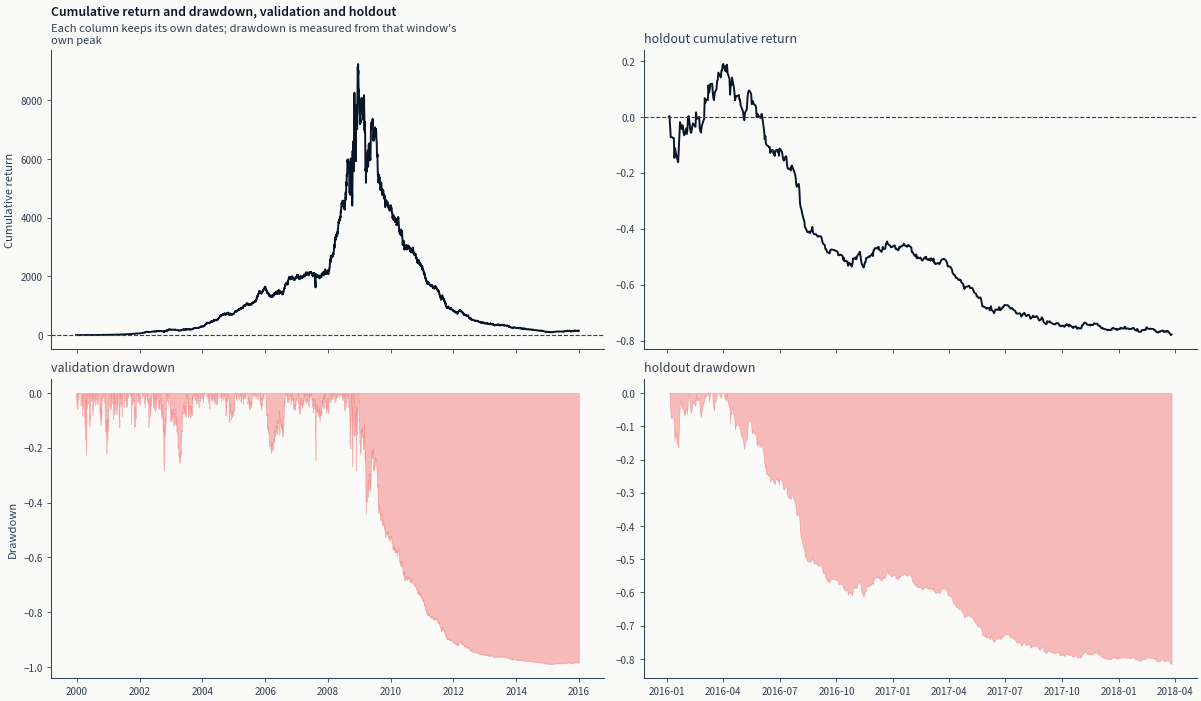

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex="col")
summary = {}
for column, period in enumerate(("validation", "holdout")):
    returns = return_frames[period]
    values = returns["daily_return"].to_numpy()
    wealth = np.cumprod(1.0 + values)
    running_peak = np.maximum.accumulate(np.concatenate(([1.0], wealth)))[1:]
    drawdown = wealth / running_peak - 1.0
    summary[period] = (float(wealth[-1] - 1.0), float(drawdown.min()))
    axes[0, column].plot(returns["timestamp"], wealth - 1.0, color=COLORS["blue"])
    axes[0, column].axhline(0, color=COLORS["neutral"], linewidth=0.8, linestyle="--")
    axes[0, column].set_title(f"{period} cumulative return")
    axes[1, column].fill_between(
        returns["timestamp"],
        drawdown,
        0,
        color=COLORS["negative"],
        alpha=0.35,
    )
    axes[1, column].set_title(f"{period} drawdown")
axes[0, 0].set_ylabel("Cumulative return")
axes[1, 0].set_ylabel("Drawdown")
add_message_title(
    axes[0, 0],
    "Cumulative return and drawdown, validation and holdout",
    subtitle="Each column keeps its own dates; drawdown is measured from that window's own peak",
)
# The alt text reads the two end points and the two troughs from the frames rather than describing
# a shape, so a window described as ending ahead when it does not is a claim the data refutes.
_read = "; ".join(
    f"{period} ends at {total:+.1%} cumulative return with a worst drawdown of {worst:.1%}"
    for period, (total, worst) in summary.items()
)
show_with_alt(
    fig,
    "Four panels in two columns, validation on the left and holdout on the right, each column "
    "sharing a time axis. The top row traces cumulative return with a dashed line at zero; the "
    f"bottom row shades the decline from each window's running peak. Read from the frames: {_read}.",
)

## Computed assessment

The statements below are generated from the registered metrics themselves. An interval that lies wholly
above or below zero provides directional evidence at its registered confidence level; an interval
spanning zero leaves the direction unresolved.

In [20]:
for row in paired_evidence.iter_rows(named=True):
    lower = row["sharpe_diff_ci95_lo"]
    upper = row["sharpe_diff_ci95_hi"]
    if lower > 0:
        interval_read = "above zero"
    elif upper < 0:
        interval_read = "below zero"
    else:
        interval_read = "spans zero"
    print(
        f"{row['comparison']}: Sharpe difference {row['sharpe_diff']:+.3f}, "
        f"interval [{lower:+.3f}, {upper:+.3f}] {interval_read}; "
        f"challenger win probability {row['prob_challenger_wins']:.3f}."
    )

holdout minus validation: Sharpe difference -3.349, interval [-4.801, -1.961] below zero; challenger win probability 0.000.
holdout minus equal weight: Sharpe difference -4.057, interval [-5.805, -2.335] below zero; challenger win probability 0.000.
validation minus equal weight: Sharpe difference +0.130, interval [-0.459, +0.750] spans zero; challenger win probability 0.666.


## What the drawdown figure does and does not say

The selected configuration carries a deep registered `max_drawdown`, and most of the candidate
population it was drawn from does too. A reader is entitled to take that as meaning the capital
was nearly gone, so it is worth settling from the stored equity path rather than from the summary
statistic.

The cell below takes the validation path apart into the peak it reached and the decline from that
peak, reports the deepest single session and the smallest margin cushion the book held, and then
counts how the candidates divide between a drawdown that gave back a gain and one that consumed
the capital committed. Those two cases carry the same `max_drawdown` and different consequences,
and the selection rule reads neither.

In [21]:
validation_returns = return_frames["validation"]["daily_return"].to_numpy()
validation_wealth = np.cumprod(1.0 + validation_returns)
peak_index = int(validation_wealth.argmax())
trough_index = int(
    (
        validation_wealth / np.maximum.accumulate(np.concatenate(([1.0], validation_wealth)))[1:]
    ).argmin()
)
validation_dates = return_frames["validation"]["timestamp"].to_list()

state_paths = [
    path for path in selected_validation.artifacts() if path.name == "portfolio_state.parquet"
]
if len(state_paths) != 1:
    raise ValueError(f"{selected_validation.hash} must have one portfolio state artifact")
state = pl.read_parquet(state_paths[0]).sort("timestamp")

# The margin requirement is read from the run's own spec rather than restated here, so the
# comparison below cannot outlive a change to the account configuration it is judging.
spec_paths = [path for path in selected_validation.artifacts() if path.name == "spec.json"]
if len(spec_paths) != 1:
    raise ValueError(f"{selected_validation.hash} must have one spec artifact")
account = json.loads(spec_paths[0].read_text())["backtest_config"]["account"]
short_maintenance_margin = float(account["short_maintenance_margin"])
equity = state["equity"].to_numpy()
gross = state["gross_exposure"].to_numpy()
# The book holds nothing on the first session, so gross exposure is zero there and the cushion is
# undefined rather than infinite. Dividing only where the book exists keeps that session out of the
# minimum instead of letting a warning stand in for it.
held = gross > 0.0
cushion = np.full(gross.shape, np.nan)
cushion[held] = equity[held] / gross[held]

print(
    f"peak wealth {validation_wealth[peak_index]:,.0f}x initial on {validation_dates[peak_index]}, "
    f"trough {validation_wealth[trough_index]:,.0f}x on {validation_dates[trough_index]}, "
    f"ending at {validation_wealth[-1]:,.0f}x"
)
print(
    f"the decline ran {trough_index - peak_index} sessions; "
    f"the worst single session was {validation_returns.min():+.2%}"
)
print(f"equity never fell below {equity.min():,.0f} against {equity[0]:,.0f} of initial cash")
print(
    f"the smallest equity-to-gross cushion was {np.nanmin(cushion):.4f}, "
    f"against a {short_maintenance_margin:.2f} short maintenance requirement"
)

# The same split across the population the selection rule ranked over. "Gave back a gain" and
# "lost the capital" are the two readings of one deep drawdown, and the count says which is
# typical here - so the paragraph below cannot be read as describing every candidate.
deep = selection_evidence.filter(pl.col("max_drawdown") <= -0.90)
recovered = deep.filter(pl.col("total_return") > 0.0).height
lost = deep.filter(pl.col("total_return") <= -0.90).height
print(
    f"\nof {selection_evidence.height} candidates, {deep.height} draw down to -90% or worse; "
    f"of those, {lost} end having lost more than 90% of the capital committed "
    f"and {recovered} end above water"
)

peak wealth 9,231x initial on 2008-12-17, trough 96x on 2015-02-25, ending at 146x
the decline ran 1606 sessions; the worst single session was -11.86%
equity never fell below 943,004 against 1,000,000 of initial cash
the smallest equity-to-gross cushion was 0.4088, against a 0.30 short maintenance requirement

of 538 candidates, 522 draw down to -90% or worse; of those, 409 end having lost more than 90% of the capital committed and 27 end above water


For the selected configuration the drawdown is a give-back of a gain: equity ends far above the
cash committed and the margin cushion stays clear of the maintenance requirement throughout, so
no margin call was owed and the engine withheld none. The counts above show that reading is the
minority one. Most candidates at the same drawdown did lose the capital, and the rule picked one
that did not, which is what ranking on Sharpe across a long window does when the window contains
a windfall.

The calendar-year table below locates that windfall, and it is why the holdout result follows.

In [22]:
for period in ("validation", "holdout"):
    frame = return_frames[period]
    yearly = (
        frame.with_columns(pl.col("timestamp").dt.year().alias("year"))
        .group_by("year")
        .agg(((1.0 + pl.col("daily_return")).product() - 1.0).alias("annual_return"))
        .sort("year")
    )
    print(f"{period}:")
    for row in yearly.iter_rows(named=True):
        print(f"  {row['year']}  {row['annual_return']:+9.2%}")

validation:
  1999     -0.56%
  2000   +670.86%
  2001   +666.11%
  2002   +222.82%
  2003    +56.94%
  2004   +142.89%
  2005   +127.50%
  2006    +19.07%
  2007    +12.61%
  2008   +247.07%
  2009    -42.81%
  2010    -47.71%
  2011    -63.89%
  2012    -51.97%
  2013    -39.54%
  2014    -53.93%
  2015    +32.14%
holdout:
  2016    -46.56%
  2017    -55.49%
  2018     -6.99%


The configuration earns its entire validation record in the 2000-2002 decline and again in 2008,
and loses money in every year from 2009 through 2014. A Sharpe ratio computed across the whole
window reports one number for two regimes, and the selection rule reads only that number. The
holdout window opens in the later regime and loses money in every year it covers, so its result
continues the 2009-2014 pattern rather than departing from it. The six consecutive losing years
that close the validation window are already visible in the data the selection was made from.

One further property is worth stating because the chapter does not otherwise measure it: the book
runs at roughly twice equity in gross exposure and turns over about its full notional each day,
and the commission and slippage registered for the validation run are large multiples of the
capital it ends with. The returns above are therefore a property of the signal under the declared
cost model, at the notional the backtest assumed.

## Key takeaways and limitations

- The immutable backtest set defines the validation search population, so registry additions made
  after it was frozen cannot change the selection.
- Validation Sharpe and the backtest hash determine the choice; predictive IC, cost sensitivity,
  and holdout performance are excluded from that rule.
- The holdout assessment follows the selected configuration's checkpoint, strategy, label,
  feature and price identities, refitted on the history that ends before the holdout opens.
- Registered paired comparisons distinguish uncertainty in a difference from the uncertainty of
  two separate point estimates.
- Validation and holdout path diagnostics retain their own time windows and are interpreted
  alongside, rather than pooled across, the validation/holdout boundary.
- The selected configuration was never distinguishable from its equal-weight benchmark on
  validation: that Sharpe difference is positive with an interval spanning zero, as the computed
  assessment above reports. The selection rule ranks on a point estimate and does not consult the
  interval, so a configuration can top the ranking on evidence this weak.
- The registered drawdown for this configuration measures a decline from a peak, not a loss of the
  committed capital, and the margin cushion never approached the short maintenance requirement.
  Across the sweep the same figure usually does mean the capital was lost, so the statistic cannot
  be read the same way from one run to the next.
- Validation Sharpe is computed across two regimes the configuration behaves oppositely in. The
  holdout window lies wholly within the second, so holdout and validation are not measuring the
  same thing even before the refit is considered.

The holdout model is fitted on every year that precedes the holdout window, while each validation
model was fitted on a rolling window of about ten years. The selection was therefore made among
models of one shape and tested on a model of another, which is a declared property of the holdout
construction rather than a defect, and a reason not to read the whole validation-to-holdout gap as
an estimate of selection bias.

This assessment covers one selected strategy lineage and its declared equal-weight benchmark. It
does not estimate live market impact, borrow availability, or capacity beyond the cost and risk
assumptions stored in the selected strategy specification.